In [1]:
import os
from pathlib import Path
import pandas as pd

if Path.cwd().name == "notebooks":
    os.chdir("..")

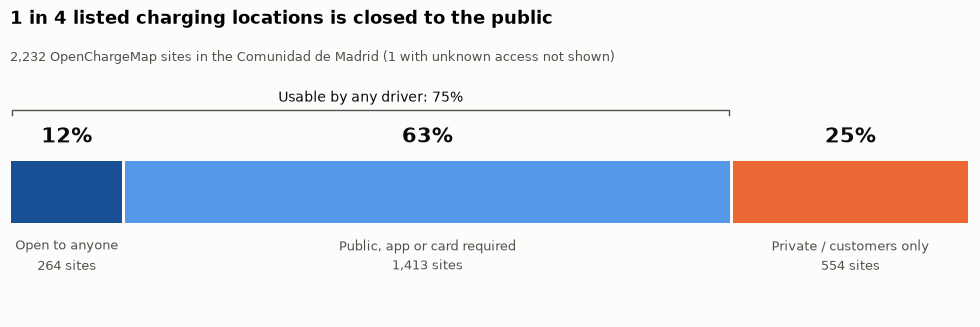

In [2]:
# Share of listed charging locations that a driver can actually use
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

ocm = pd.read_csv("data/raw/ocm/ocm_chargers.csv")
munis_ = gpd.read_file("data/raw/boundaries/municipios.gpkg")
sites = gpd.GeoDataFrame(ocm, geometry=gpd.points_from_xy(ocm["lon"], ocm["lat"]), crs=4326).to_crs(munis_.crs)
sites = gpd.sjoin(sites, munis_[["geometry"]], how="inner", predicate="within")     # inside the Comunidad only

CATS = [  # (access_class, label, colour)
    ("public",            "Open to anyone",                "#184f95"),
    ("public_membership", "Public, app or card required",  "#5598e7"),
    ("restricted",        "Private / customers only",      "#eb6834"),
]
counts = sites["access_class"].value_counts()
n_total = int(counts.sum())
n_other = n_total - int(sum(counts.get(c, 0) for c, _, _ in CATS))
share = {c: counts.get(c, 0) / n_total for c, _, _ in CATS}
usable = share["public"] + share["public_membership"]

SURFACE, INK, INK_2 = "#fcfcfb", "#0b0b0b", "#52514e"
fig, ax = plt.subplots(figsize=(10, 3.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
left = 0.0
for c, label, colour in CATS:
    w = share[c]
    ax.barh(0, w - 0.003, left=left + 0.0015, height=0.5, color=colour)         # thin gap between segments
    ax.text(left + w / 2, 0.36, f"{w:.0%}", ha="center", va="bottom", fontsize=15, fontweight="bold", color=INK)
    ax.text(left + w / 2, -0.36, f"{label}\n{counts.get(c, 0):,} sites", ha="center", va="top",
            fontsize=9.5, color=INK_2, linespacing=1.4)
    left += w

# Bracket over the usable part
y = 0.66
ax.plot([0.002, 0.002, usable - 0.002, usable - 0.002], [y - 0.04, y, y, y - 0.04], color=INK_2, lw=1)
ax.text(usable / 2, y + 0.04, f"Usable by any driver: {usable:.0%}", ha="center", va="bottom",
        fontsize=10, color=INK)

ax.set_xlim(0, 1); ax.set_ylim(-1.0, 0.95); ax.axis("off")
fig.suptitle(f"1 in {1 / share['restricted']:.0f} listed charging locations is closed to the public",
             x=0.02, ha="left", fontsize=13, fontweight="bold")
note = f"{n_total:,} OpenChargeMap sites in the Comunidad de Madrid"
if n_other:
    note += f" ({n_other} with unknown access not shown)"
fig.text(0.02, 0.82, note, fontsize=9, color=INK_2)
fig.subplots_adjust(left=0.02, right=0.98, top=0.78, bottom=0.02)
Path("maps").mkdir(exist_ok=True)
fig.savefig("maps/02_share_public.png", dpi=200)
plt.show()

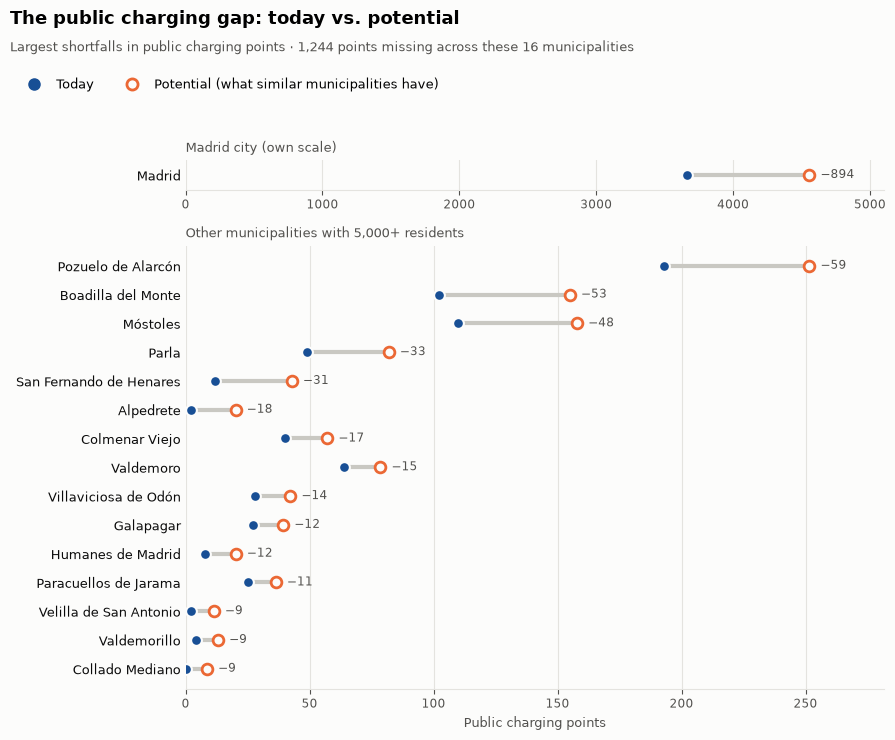

In [3]:
# Current public charging points vs. the model's "potential" (what similar municipalities have)
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

MIN_POP, TOP_N = 5_000, 15
CURRENT, POTENTIAL, LINE = "#184f95", "#eb6834", "#c9c8c2"
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"

pred = pd.read_csv("data/processed/model_predictions.csv", dtype={"ine_code": str})
pred["gap"] = pred["expected"] - pred["public_points"]
short = pred[(pred["population"] >= MIN_POP) & (pred["gap"] > 0)].nlargest(TOP_N + 1, "gap")
madrid = short[short["ine_code"] == "28079"]
rest = short[short["ine_code"] != "28079"].head(TOP_N).iloc[::-1]          # biggest gap at the top

def dumbbell(ax, df):
    y = range(len(df))
    ax.hlines(y, df["public_points"], df["expected"], color=LINE, linewidth=3, zorder=1)
    ax.scatter(df["public_points"], y, s=60, color=CURRENT, zorder=3, edgecolor=SURFACE, linewidth=1.5)
    ax.scatter(df["expected"], y, s=60, facecolor=SURFACE, edgecolor=POTENTIAL, linewidth=2, zorder=3)
    for yi, (_, r) in zip(y, df.iterrows()):
        ax.annotate(f"−{r['gap']:,.0f}", (r["expected"], yi), xytext=(8, 0), textcoords="offset points",
                    va="center", fontsize=8.5, color=INK_2)
    ax.set_yticks(list(y), df["name"])
    ax.tick_params(axis="y", length=0, labelsize=9.5, labelcolor=INK)
    ax.tick_params(axis="x", colors=INK_2, labelsize=8.5)
    ax.grid(axis="x", color=GRID, linewidth=0.8); ax.set_axisbelow(True)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.set_xlim(0, df["expected"].max() * 1.12)

has_madrid = len(madrid) > 0
fig, axes = plt.subplots(2 if has_madrid else 1, 1, figsize=(9, 7.5), facecolor=SURFACE,
                         gridspec_kw={"height_ratios": [1, TOP_N]} if has_madrid else None,
                         squeeze=False)
for a in axes[:, 0]:
    a.set_facecolor(SURFACE)
if has_madrid:
    dumbbell(axes[0, 0], madrid)
    axes[0, 0].set_title("Madrid city (own scale)", loc="left", fontsize=9, color=INK_2)
dumbbell(axes[-1, 0], rest)
axes[-1, 0].set_title("Other municipalities with 5,000+ residents", loc="left", fontsize=9, color=INK_2)
axes[-1, 0].set_xlabel("Public charging points", color=INK_2, fontsize=9)

handles = [Line2D([], [], marker="o", ls="", markersize=8, color=CURRENT, label="Today"),
           Line2D([], [], marker="o", ls="", markersize=8, markerfacecolor=SURFACE, markeredgecolor=POTENTIAL,
                  markeredgewidth=2, label="Potential (what similar municipalities have)")]
fig.legend(handles=handles, loc="upper left", bbox_to_anchor=(0.01, 0.905), ncol=2, frameon=False, fontsize=9)

total = short["gap"].sum()
fig.suptitle("The public charging gap: today vs. potential", x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.text(0.01, 0.925, f"Largest shortfalls in public charging points · {total:,.0f} points missing across "
         f"these {len(short) if has_madrid else len(rest)} municipalities", fontsize=9, color=INK_2)
fig.tight_layout(rect=(0, 0, 1, 0.87))
Path("maps").mkdir(exist_ok=True)
fig.savefig("maps/04_gap_today_vs_potential.png", dpi=200)
plt.show()